In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('student_mental_health_burnout.csv')

In [3]:
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
df = df.drop('student_id', axis=1)

In [5]:
le = LabelEncoder()
categorical_cols = ['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']

In [6]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [7]:
df.head()

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,23,1,3,0,4.3,6.8,6.1,0,10,3,4,2,6,1.8,0,66.5,9.63,1,0
1,20,1,3,2,1.4,4.7,3.0,0,2,10,8,5,9,1.9,2,55.8,6.04,2,1
2,24,0,1,3,3.7,4.8,1.5,1,2,7,8,6,3,0.8,1,85.0,8.31,1,0
3,21,1,2,3,1.6,6.7,7.0,0,3,3,4,9,9,0.7,2,89.1,5.95,1,0
4,23,2,2,3,2.0,6.7,5.4,0,7,7,6,4,4,1.7,1,58.7,8.51,1,1


In [8]:
X = df.drop('burnout_level', axis=1)

In [9]:
y = df['burnout_level']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [12]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred = rf_model.predict(X_test)

In [14]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 33.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.34      0.34      0.34     10021
           1       0.34      0.35      0.34     10024
           2       0.33      0.31      0.32      9955

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.33     30000
weighted avg       0.33      0.33      0.33     30000



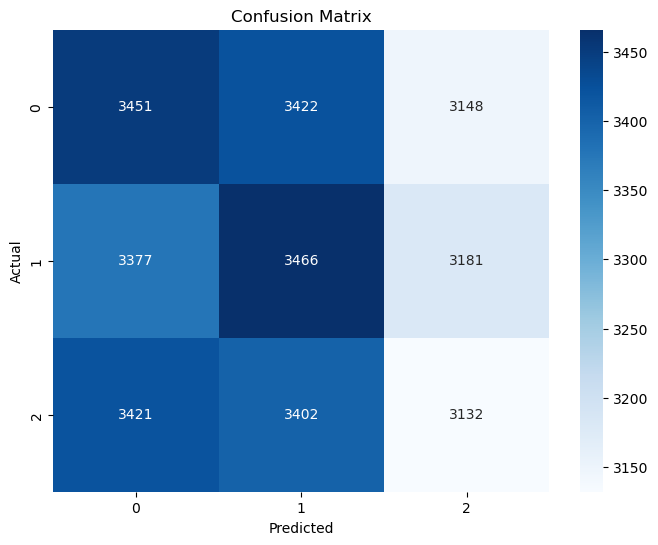

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()